In [56]:
import pandas as pd
import numpy as np
import sys
sys.path.append('..') #manually adds the parent directory to that search path

In [57]:
from scripts.memory_reducer import memory_reducer

In [58]:

prices = memory_reducer('../data/stock_prices.csv')
sp500  = memory_reducer('../data/sp500.csv')

In [59]:
print(prices.shape)
print(prices.head())

(3644, 544)
        Date          A         AA      AAPL  ABBV        ABC        ABT  \
0 2000-12-12  38.407539  24.494158  1.040282   NaN   9.300099  40.196083   
1 2000-12-13  39.038158  25.323023  1.014579   NaN   9.513010  41.493507   
2 2000-12-14  39.749287  24.594860  0.976702   NaN   9.766690  38.538265   
3 2000-12-15  38.159313  23.967402  0.950999   NaN  10.419011  37.489113   
4 2000-12-18  38.239819  25.028660  0.963850   NaN  10.899191  39.691528   

         ACE       ACI  ACN  ...        XOM       XRAY       XRX  XYL  \
0  31.011162  4.238186  NaN  ...  31.374321  11.567391  4.709991  NaN   
1  29.534441  4.238186  NaN  ...  31.783897  11.743035  4.872701  NaN   
2  28.796080  4.238186  NaN  ...  30.990116  11.567391  5.403645  NaN   
3  28.102020  4.100917  NaN  ...  30.489925  11.683442  5.352263  NaN   
4  29.165260  4.289662  NaN  ...  31.309078  11.918679  5.463590  NaN   

        YHOO       YUM       ZION    ZLC  ZMH  ZNGA  
0  17.905001  7.531124  49.197350  13.

In [60]:
print(sp500.shape)
print(sp500.head())

(3770, 7)
        Date         Open         High          Low        Close  \
0 2014-12-26  2084.300049  2092.699951  2084.300049  2088.770020   
1 2014-12-24  2083.250000  2087.560059  2081.860107  2081.879883   
2 2014-12-23  2081.479980  2086.729980  2079.770020  2082.169922   
3 2014-12-22  2069.280029  2078.760010  2069.280029  2078.540039   
4 2014-12-19  2061.040039  2077.850098  2061.030029  2070.649902   

         Volume  Adjusted Close  
0  1.735230e+09     2088.770020  
1  1.416980e+09     2081.879883  
2  3.043950e+09     2082.169922  
3  3.369520e+09     2078.540039  
4  6.465530e+09     2070.649902  


In [61]:
 # Melt prices from wide to long

In [62]:
prices = prices.melt(id_vars='Date', var_name='ticker', value_name='Price')
print(prices.shape)
print(prices.head(10))

(1978692, 3)
        Date ticker      Price
0 2000-12-12      A  38.407539
1 2000-12-13      A  39.038158
2 2000-12-14      A  39.749287
3 2000-12-15      A  38.159313
4 2000-12-18      A  38.239819
5 2000-12-19      A  38.280071
6 2000-12-20      A  35.220886
7 2000-12-21      A  34.469509
8 2000-12-22      A  36.690102
9 2000-12-26      A  35.891762


In [63]:
# Resample to month-end

In [64]:
prices = prices.set_index('Date')
prices = prices.groupby('ticker')['Price'].resample('ME').last() # select a single column -> series
print(prices.shape)
print(prices.head(15))

(91767,)
ticker  Date      
A       2000-12-31    36.730354
        2001-01-31    36.596180
        2001-02-28    24.151464
        2001-03-31    20.615959
        2001-04-30    26.170795
        2001-05-31    22.501116
        2001-06-30    21.803406
        2001-07-31    19.193707
        2001-08-31    17.778162
        2001-09-30    13.115587
        2001-10-31    14.940365
        2001-11-30    18.294735
        2001-12-31    19.126619
        2002-01-31    20.361027
        2002-02-28    20.897726
Name: Price, dtype: float32


In [65]:
prices = prices.reset_index()
print(type(prices))
print(prices.shape)
print(prices.head())

<class 'pandas.core.frame.DataFrame'>
(91767, 3)
  ticker       Date      Price
0      A 2000-12-31  36.730354
1      A 2001-01-31  36.596180
2      A 2001-02-28  24.151464
3      A 2001-03-31  20.615959
4      A 2001-04-30  26.170795


In [66]:
# Filter price outliers

In [67]:
# remove any price outside the range $0.10 to $10,000.
prices = prices[(prices['Price'] >= 0.1) & (prices['Price'] <= 10000)]
print(prices.shape)

(83889, 3)


In [68]:
# Compute monthly returns

In [69]:
prices = prices.sort_values(['ticker', 'Date'])

prices['monthly_past_return'] = prices.groupby('ticker')['Price'].transform(
    lambda x: (x - x.shift(1)) / x.shift(1)
)

prices['monthly_future_return'] = prices.groupby('ticker')['Price'].transform(
    lambda x: (x.shift(-1) - x) / x
)

print(prices.head(10))

  ticker       Date      Price  monthly_past_return  monthly_future_return
0      A 2000-12-31  36.730354                  NaN              -0.003653
1      A 2001-01-31  36.596180            -0.003653              -0.340055
2      A 2001-02-28  24.151464            -0.340055              -0.146389
3      A 2001-03-31  20.615959            -0.146389               0.269444
4      A 2001-04-30  26.170795             0.269444              -0.140220
5      A 2001-05-31  22.501116            -0.140220              -0.031008
6      A 2001-06-30  21.803406            -0.031008              -0.119692
7      A 2001-07-31  19.193707            -0.119692              -0.073750
8      A 2001-08-31  17.778162            -0.073750              -0.262264
9      A 2001-09-30  13.115587            -0.262264               0.139130


In [70]:
mask_not_crisis = ~prices['Date'].dt.year.isin([2008, 2009])
mask_outlier = (prices['monthly_past_return'] > 1) | (prices['monthly_past_return'] < -0.5)

prices.loc[mask_not_crisis & mask_outlier, 'monthly_past_return'] = np.nan
prices.loc[mask_not_crisis & mask_outlier, 'monthly_future_return'] = np.nan

print(prices.shape)
print(prices['monthly_past_return'].isna().sum())

(83889, 5)
603


In [71]:
 # Fill missing values per company

In [72]:
# forward fill -> you carry the last known value forward in time
prices['monthly_past_return'] = prices.groupby('ticker')['monthly_past_return'].transform(
    lambda x: x.ffill() # forward fill
)
prices['monthly_future_return'] = prices.groupby('ticker')['monthly_future_return'].transform(
    lambda x: x.ffill() # forward fill
)

#these are companies whose very first rows are NaN
prices = prices.dropna()
print(prices.isna().sum())
print(prices.shape)
prices.head()

ticker                   0
Date                     0
Price                    0
monthly_past_return      0
monthly_future_return    0
dtype: int64
(83345, 5)


,ticker,Date,Price,monthly_past_return,monthly_future_return
1,A,2001-01-31,36.596180,-0.003653,-0.340055
2,A,2001-02-28,24.151464,-0.340055,-0.146389
3,A,2001-03-31,20.615959,-0.146389,0.269444
4,A,2001-04-30,26.170795,0.269444,-0.140220
5,A,2001-05-31,22.501116,-0.140220,-0.031008


In [73]:
# Set the MultiIndex
prices = prices.set_index(['Date', 'ticker'])
print(prices.head())
# used 'ME' (month end) which is the newer pandas 

                       Price  monthly_past_return  monthly_future_return
Date       ticker                                                       
2001-01-31 A       36.596180            -0.003653              -0.340055
2001-02-28 A       24.151464            -0.340055              -0.146389
2001-03-31 A       20.615959            -0.146389               0.269444
2001-04-30 A       26.170795             0.269444              -0.140220
2001-05-31 A       22.501116            -0.140220              -0.031008


In [74]:
# preprocess sp500
sp500 = sp500.set_index('Date')
sp500 = sp500['Adjusted Close'].resample('ME').last()
sp500 = sp500.to_frame() # move back to a dataframe.
sp500['monthly_past_return'] = (sp500['Adjusted Close'] - sp500['Adjusted Close'].shift(1)) / sp500['Adjusted Close'].shift(1)
sp500 = sp500.dropna()
print(sp500.head())
print(sp500.shape)

            Adjusted Close  monthly_past_return
Date                                           
2000-02-29     1366.420044            -0.020108
2000-03-31     1498.579956             0.096720
2000-04-30     1452.430054            -0.030796
2000-05-31     1420.599976            -0.021915
2000-06-30     1454.599976             0.023934
(179, 2)


In [75]:
#  EDA — Exploratory Data Analysis

In [76]:
raw_prices = memory_reducer('../data/stock_prices.csv')
raw_prices = raw_prices.melt(id_vars='Date', var_name='ticker', value_name='Price')

print("Total missing values:", raw_prices['Price'].isna().sum())
print("Missing values by year:")
print(raw_prices.groupby(raw_prices['Date'].dt.year)['Price'].apply(lambda x: x.isna().sum())) # .com buble

Total missing values: 196717
Missing values by year:
Date
2000     1170
2001    27628
2002    22023
2003    20443
2004    20397
2005    17205
2006    15147
2007    13959
2008    11032
2009    11260
2010     9924
2011     7717
2012     7221
2013     5264
2014     6327
Name: Price, dtype: int64


In [77]:
import matplotlib.pyplot as plt

# Statistical summary
print(raw_prices['Price'].describe())

count    1.781975e+06
mean     1.596735e+04
std      4.272523e+05
min      0.000000e+00
25%      1.680405e+01
50%      2.823071e+01
75%      4.549323e+01
max      9.387060e+07
Name: Price, dtype: float64


In [78]:
# Find the most extreme prices
outliers = raw_prices[raw_prices['Price'] > 10000].sort_values('Price', ascending=False)
print(outliers.head(20))
low_outliers = raw_prices[(raw_prices['Price'] > 0) & (raw_prices['Price'] < 0.1)].sort_values('Price')
print(low_outliers.head(10))

              Date ticker       Price
1642830 2012-08-15   SPLS  93870600.0
1643236 2014-03-06   SPLS  69142304.0
1642964 2013-02-19   SPLS  68197696.0
1642505 2011-05-18   SPLS  62315700.0
1642189 2010-03-02   SPLS  49567700.0
1642852 2012-09-14   SPLS  46912200.0
1643095 2013-08-21   SPLS  45490400.0
1642710 2012-02-29   SPLS  43527700.0
1642965 2013-02-20   SPLS  42068600.0
1643360 2014-09-02   SPLS  42005196.0
1643416 2014-11-19   SPLS  41589800.0
1642570 2011-08-17   SPLS  40973600.0
1642190 2010-03-03   SPLS  40574200.0
1642564 2011-08-09   SPLS  39938800.0
1642859 2012-09-25   SPLS  39791400.0
1642851 2012-09-13   SPLS  39489700.0
1643288 2014-05-20   SPLS  38518468.0
1642975 2013-03-06   SPLS  38190500.0
1642765 2012-05-16   SPLS  37943700.0
1640301 2002-11-19   SPLS  37231300.0
              Date ticker         Price
1661630 2014-11-11    STT  1.401298e-45
1679840 2014-10-28    SWY  1.401298e-45
1690777 2014-11-04    SYY  2.802597e-45
626726  2014-10-30    EMC  4.203895e-45
44

In [79]:
outliers_text = """Outliers identified in stock_prices.csv
========================================

High price outliers (likely volume data in price column):
1. ticker: SPLS, date: 2012-08-15, price: 93870600.0
2. ticker: SPLS, date: 2014-03-06, price: 69142304.0
3. ticker: SPLS, date: 2011-05-18, price: 62315700.0

Low price outliers (float underflow errors):
4. ticker: STT, date: 2014-11-11, price: 1.401298e-45
5. ticker: SWY, date: 2014-10-28, price: 1.401298e-45
6. ticker: EMC, date: 2014-10-30, price: 4.203895e-45
"""

with open('../results/outliers.txt', 'w') as f:
    f.write(outliers_text)

print("saved")

saved


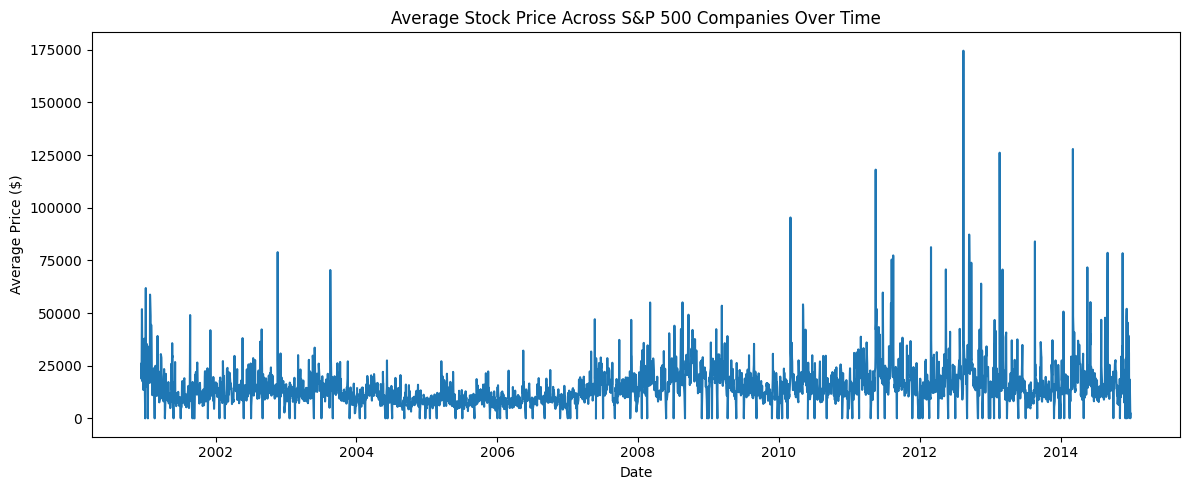

In [80]:
def plot_avg_price(df, plot=False):
    avg_price = df.groupby('Date')['Price'].mean()
    
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(avg_price.index, avg_price.values)
    ax.set_title('Average Stock Price Across S&P 500 Companies Over Time')
    ax.set_xlabel('Date')
    ax.set_ylabel('Average Price ($)')
    plt.tight_layout()
    plt.savefig('../results/plots/avg_price.png')
    
    if plot:
        plt.show()
    plt.close() # clean from memory. 

plot_avg_price(raw_prices, plot=True)

# 2001-2002 is the dot-com crash
# 2013 is almost certainly SPLS  -> ake million-dollar prices pulling the average up enormously


In [81]:

# Part 3: Create Signal

In [82]:
prices = prices.reset_index()

In [83]:
# rolling average (window=3)
prices['average_return_1y'] = prices.groupby('ticker')['monthly_past_return'].transform(
    lambda x: x.rolling(12).mean()
)
print(prices.head(20))

         Date ticker      Price  monthly_past_return  monthly_future_return  \
0  2001-01-31      A  36.596180            -0.003653              -0.340055   
1  2001-02-28      A  24.151464            -0.340055              -0.146389   
2  2001-03-31      A  20.615959            -0.146389               0.269444   
3  2001-04-30      A  26.170795             0.269444              -0.140220   
4  2001-05-31      A  22.501116            -0.140220              -0.031008   
5  2001-06-30      A  21.803406            -0.031008              -0.119692   
6  2001-07-31      A  19.193707            -0.119692              -0.073750   
7  2001-08-31      A  17.778162            -0.073750              -0.262264   
8  2001-09-30      A  13.115587            -0.262264               0.139130   
9  2001-10-31      A  14.940365             0.139130               0.224517   
10 2001-11-30      A  18.294735             0.224517               0.045471   
11 2001-12-31      A  19.126619             0.045471

In [84]:
prices['signal'] = prices.groupby('Date')['average_return_1y'].transform(
    lambda x: x.rank(ascending=False) <= 20
)

print(prices[prices['signal'] == True].head(10))
print(prices['signal'].value_counts())

          Date ticker      Price  monthly_past_return  monthly_future_return  \
329 2014-06-30     AA  14.862878             0.094048               0.100739   
330 2014-07-31     AA  16.360146             0.100739               0.015272   
331 2014-08-31     AA  16.610001             0.015272              -0.031306   
332 2014-09-30     AA  16.090000            -0.031306               0.041641   
333 2014-10-31     AA  16.760000             0.041641               0.031623   
334 2014-11-30     AA  17.290001             0.031623              -0.083285   
381 2004-10-31   AAPL   3.544263             0.352258               0.279580   
382 2004-11-30   AAPL   4.535169             0.279580              -0.039523   
383 2004-12-31   AAPL   4.355927            -0.039523               0.194099   
384 2005-01-31   AAPL   5.201409             0.194099               0.166710   

     average_return_1y  signal  
329           0.057188    True  
330           0.064197    True  
331           0.0677

In [85]:
# PnL Profit and Loss

In [86]:
# PnL of our strategy
pnl_strategy = prices['signal'] * prices['monthly_future_return']

In [87]:
# total return = PnL / number of stocks we invested in each month
total_return_strategy = pnl_strategy.sum() / prices['signal'].sum()

In [88]:
print(f"Strategy PnL: {pnl_strategy.sum():.2f}")
print(f"Strategy total return: {total_return_strategy:.2%}")

Strategy PnL: 68.53
Strategy total return: 2.18%


In [89]:
# SP500 benchmark
pnl_sp500 = pd.Series(20, index=sp500.index) * sp500['monthly_past_return']
total_return_sp500 = pnl_sp500.sum() / pd.Series(20, index=sp500.index).sum()

print(f"SP500 PnL: {pnl_sp500.sum():.2f}")
print(f"SP500 total return: {total_return_sp500:.2%}")

SP500 PnL: 11.59
SP500 total return: 0.32%


In [90]:
results_text = f"""Backtesting Results
===================

Stock Picking Strategy (Top 20 momentum stocks):
- Total PnL: {pnl_strategy.sum():.2f}$
- Total Return: {total_return_strategy:.2%}

S&P 500 Benchmark (investing 20$ each month):
- Total PnL: {pnl_sp500.sum():.2f}$
- Total Return: {total_return_sp500:.2%}

Conclusion:
The stock picking strategy outperformed the S&P 500 benchmark.
"""

with open('../results/results.txt', 'w') as f:
    f.write(results_text)

print("saved")

saved


In [98]:
def plot_performance(pnl_strategy, pnl_sp500, plot=False):
    
    cumulative_strategy = pnl_strategy.groupby(level='Date').sum().cumsum()
    cumulative_sp500 = pnl_sp500.cumsum()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(cumulative_strategy.index, cumulative_strategy.values, label='Stock Picking 20')
    ax.plot(cumulative_sp500.index, cumulative_sp500.values, label='SP500')
    ax.set_title('Cumulative Performance: Stock Picking vs S&P 500')
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative PnL ($)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../results/plots/performance.png')
    
    if plot:
        plt.show()
    plt.close()

plot_performance(pnl_strategy, pnl_sp500, plot=True)

ValueError: level name Date is not the name of the index

In [99]:
print(pnl_strategy.index)
print(pnl_strategy.head())

RangeIndex(start=0, stop=83345, step=1)
0   -0.0
1   -0.0
2    0.0
3   -0.0
4   -0.0
dtype: float32


In [100]:

print(prices.index)
print(prices.head())

MultiIndex([('2001-01-31',    'A'),
            ('2001-02-28',    'A'),
            ('2001-03-31',    'A'),
            ('2001-04-30',    'A'),
            ('2001-05-31',    'A'),
            ('2001-06-30',    'A'),
            ('2001-07-31',    'A'),
            ('2001-08-31',    'A'),
            ('2001-09-30',    'A'),
            ('2001-10-31',    'A'),
            ...
            ('2014-03-31', 'ZNGA'),
            ('2014-04-30', 'ZNGA'),
            ('2014-05-31', 'ZNGA'),
            ('2014-06-30', 'ZNGA'),
            ('2014-07-31', 'ZNGA'),
            ('2014-08-31', 'ZNGA'),
            ('2014-09-30', 'ZNGA'),
            ('2014-10-31', 'ZNGA'),
            ('2014-11-30', 'ZNGA'),
            ('2014-12-31', 'ZNGA')],
           names=['Date', 'ticker'], length=83345)
                       Price  monthly_past_return  monthly_future_return  \
Date       ticker                                                          
2001-01-31 A       36.596180            -0.003653           

In [101]:
pnl_strategy = prices['signal'] * prices['monthly_future_return']
pnl_strategy.index = prices.index

print(pnl_strategy.index)
print(pnl_strategy.head())

MultiIndex([('2001-01-31',    'A'),
            ('2001-02-28',    'A'),
            ('2001-03-31',    'A'),
            ('2001-04-30',    'A'),
            ('2001-05-31',    'A'),
            ('2001-06-30',    'A'),
            ('2001-07-31',    'A'),
            ('2001-08-31',    'A'),
            ('2001-09-30',    'A'),
            ('2001-10-31',    'A'),
            ...
            ('2014-03-31', 'ZNGA'),
            ('2014-04-30', 'ZNGA'),
            ('2014-05-31', 'ZNGA'),
            ('2014-06-30', 'ZNGA'),
            ('2014-07-31', 'ZNGA'),
            ('2014-08-31', 'ZNGA'),
            ('2014-09-30', 'ZNGA'),
            ('2014-10-31', 'ZNGA'),
            ('2014-11-30', 'ZNGA'),
            ('2014-12-31', 'ZNGA')],
           names=['Date', 'ticker'], length=83345)
Date        ticker
2001-01-31  A        -0.0
2001-02-28  A        -0.0
2001-03-31  A         0.0
2001-04-30  A        -0.0
2001-05-31  A        -0.0
dtype: float32


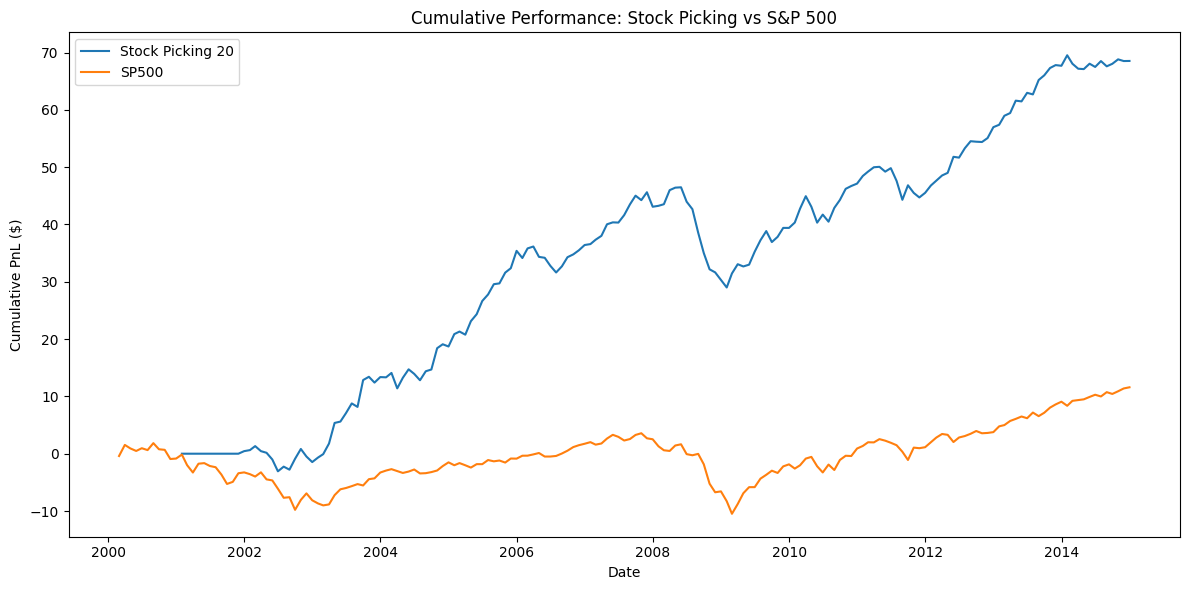

In [102]:
def plot_performance(pnl_strategy, pnl_sp500, plot=False):
    
    cumulative_strategy = pnl_strategy.groupby(level='Date').sum().cumsum()
    cumulative_sp500 = pnl_sp500.cumsum()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(cumulative_strategy.index, cumulative_strategy.values, label='Stock Picking 20')
    ax.plot(cumulative_sp500.index, cumulative_sp500.values, label='SP500')
    ax.set_title('Cumulative Performance: Stock Picking vs S&P 500')
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative PnL ($)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../results/plots/performance.png')
    
    if plot:
        plt.show()
    plt.close()

plot_performance(pnl_strategy, pnl_sp500, plot=True)